In [4]:
import os
import sys
PROJECT_ROOT = '/storage/scratch1/3/grubin6/2AFC'
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt


In [5]:
from notebook_tools.io import read_ops


In [6]:
list_session_data_path = [
    '/home/ihsan/Desktop/data/Georgia_Tech/2AFC/Data/2p/YH24LG_CRBL_lobulev_20250814_2afc-584',
    # '/home/ihsan/Desktop/data/Georgia_Tech/2AFC/Data/2p/YH24LG_CRBL_lobulev_20250811_2afc-580',
    # '/home/ihsan/Desktop/data/Georgia_Tech/2AFC/Data/2p/YH24LG_CRBL_lobulev_20250808_2afc-577',
    # '/home/ihsan/Desktop/data/Georgia_Tech/2AFC/Data/2p/YH24LG_CRBL_lobulev_20250805_2afc-568',
]

list_ops = read_ops(list_session_data_path)

In [7]:
from notebook_tools.io import create_memmap, get_memmap_path, read_masks


In [8]:
from notebook_tools.io import read_dff


In [9]:
from notebook_tools.io import read_raw_voltages


In [10]:
from notebook_tools.io import read_bpod_mat_data


In [11]:
from notebook_tools.io import remove_start_impulse, correct_vol_start, get_trigger_time, get_session_start_time, correct_time_img_center, save_trials


In [10]:
for ops in list_ops:

    print('--- Processing session ---')
    print('Processing session data in:')
    print(ops['save_path0'])
    print('-------------------------------')

    print('Reading dff traces and voltage recordings')
    dff = read_dff(ops)
    [vol_time, vol_start, vol_stim_vis, vol_img,
        vol_hifi, vol_stim_aud, vol_flir,
        vol_pmt, vol_led] = read_raw_voltages(ops)
    vol_stim_vis = remove_start_impulse(vol_time, vol_stim_vis)
    vol_stim_vis = correct_vol_start(vol_stim_vis)
    session_start_time = get_session_start_time(vol_time, vol_start)
    trial_labels = read_bpod_mat_data(ops, session_start_time, vol_time, vol_start, vol_stim_vis)
    print('Correcting 2p camera trigger time')
    # signal trigger time stamps.
    time_img, _   = get_trigger_time(vol_time, vol_img)
    # correct imaging timing.
    time_neuro = correct_time_img_center(time_img)
    # save the final data.
    print('Saving trial data')
    save_trials(
        ops, time_neuro, dff, trial_labels,
        vol_time, vol_stim_vis,
        vol_stim_aud, vol_flir,
        vol_pmt, vol_led)


--- Processing session ---
Processing session data in:
/home/ihsan/Desktop/data/Georgia_Tech/2AFC/Data/2p/YH24LG_CRBL_lobulev_20250814_2afc-584
-------------------------------
Reading dff traces and voltage recordings
Correcting 2p camera trigger time
Saving trial data


In [84]:
from notebook_tools.io import read_trial_label, zscore_normalize, read_neural_trials


In [85]:
import pandas as pd
list_neural_trials = []
for ops in list_ops:
    print('--- Processing session ---')
    print('Processing session data in:')
    print(ops['save_path0'])
    print('-------------------------------')
    print('Reading trailized neural traces with stimulus alignment')
    neural_trials = read_neural_trials(ops, 0)
    list_neural_trials.append(neural_trials)


--- Processing session ---
Processing session data in:
/home/ihsan/Desktop/data/Georgia_Tech/2AFC/Data/2p/YH24LG_CRBL_lobulev_20250814_2afc-584
-------------------------------
Reading trailized neural traces with stimulus alignment


## GLM


dff data of a single sessions


In [86]:
from scipy import interpolate
# Binary arrays of each event in session

neural_trials = list_neural_trials[0]

dff = neural_trials['dff']
time = neural_trials['time']

# shape of dff and time
print('dff shape:', dff.shape)
print('time shape:', time.shape)

if dff.shape[1] != time.shape[0]:
    print('Warning: dff timepoints and time length do not match!')
    if abs(dff.shape[1] - time.shape[0]) < 10:
        print('Interpolating dff to match time length.')
        f_interp = interpolate.interp1d(
            np.arange(dff.shape[1]),
            dff,
            kind='linear',
            axis=1,
            fill_value='extrapolate')
        dff = f_interp(np.linspace(0, dff.shape[1]-1, time.shape[0]))
        print('New dff shape:', dff.shape)
    else:
        raise ValueError('dff timepoints and time length differ significantly!')
    
n_trials = neural_trials['trial_labels'].shape[0]

# Creating arrays
stimulus = np.zeros(time.shape[0])
# Servo In array
servo_in = np.zeros(time.shape[0])
# Licking array
licking = np.zeros(time.shape[0])
# Reward array
reward = np.zeros(time.shape[0])
# Punish array
punish = np.zeros(time.shape[0])
# prediction 
predction = np.zeros(time.shape[0])

for t in range(n_trials):
    trial_start = neural_trials['trial_labels'].loc[t, 'time_trial_start']
    trial_end = neural_trials['trial_labels'].loc[t, 'time_trial_end']
    stim_seq = neural_trials['trial_labels'].loc[t, 'stim_seq']
    # Find indices in time array
    start_idx = np.searchsorted(time, trial_start)
    end_idx = np.searchsorted(time, trial_end)
    # Iterate over each row of stim_seq
    for i in range(stim_seq.shape[0]):  # Loop over rows
        stim_onset = stim_seq[i, 0]  # Onset time (first column)
        stim_offset = stim_seq[i, 1]  # Offset time (second column)
        onset_idx = np.searchsorted(time, stim_onset)  # Scalar index
        offset_idx = np.searchsorted(time, stim_offset)  # Scalar index
        stimulus[onset_idx:offset_idx] = 1  # Mark stimulus period

    servo_onset = neural_trials['trial_labels'].loc[t, 'state_window_choice']
    servo_onset_time = servo_onset[0]
    servo_offset_time = servo_onset[1]
    start_idx = np.searchsorted(time, servo_onset_time)
    end_idx = np.searchsorted(time, servo_offset_time)
    # Servo In event
    servo_in[start_idx:end_idx] = 1

    lick_events = neural_trials['trial_labels'].loc[t, 'lick'][0]
    lick_start_time = lick_events[0]
    lick_end_time = lick_events[-1]
    start_idx = np.searchsorted(time, lick_start_time)
    end_idx = np.searchsorted(time, lick_end_time) + 1
    # Licking event
    licking[start_idx:end_idx] = 1
    # Reward event
    # reward_state = neural_trials['trial_labels'].loc[t, 'state_reward']
    # if not np.isnan(reward_state[0]):
    #     reward_start_time = reward_state[0]
    #     reward_end_time = reward_state[1]
    #     start_idx = np.searchsorted(time, reward_start_time)
    #     end_idx = np.searchsorted(time, reward_end_time)
    #     reward[start_idx:end_idx] = 1
    if neural_trials['trial_labels'].loc[t, 'outcome'] == 'reward':
        reward[start_idx:end_idx] = 1
    elif neural_trials['trial_labels'].loc[t, 'outcome'] == 'punish':
        punish[start_idx:end_idx] = 1
    
    # # Punish event
    # punish_state = neural_trials['trial_labels'].loc[t, 'state_punish']
    # if not np.isnan(punish_state[0]):
    #     punish_start_time = punish_state[0]
    #     punish_end_time = punish_state[1]
    #     start_idx = np.searchsorted(time, punish_start_time)
    #     end_idx = np.searchsorted(time, punish_end_time)
    #     punish[start_idx:end_idx] = 1
    
    # Prediction event
    if neural_trials['trial_labels'].loc[t, 'trial_type'] == 1:
        prediction_time = neural_trials['trial_labels'].loc[t, 'expected_stim']
        pred_idx = np.searchsorted(time, prediction_time)[0]
        start_idx = pred_idx - 6 if pred_idx - 6 >= 0 else 0
        end_idx = pred_idx + 6 if pred_idx + 6 <= time.shape[0] else time.shape[0]
        predction[start_idx:end_idx] = 1

session_stim_dict = {
    'stimulus': stimulus,
    'servo_in': servo_in,
    'licking': licking,
    'reward': reward,
    'punish': punish,
    'prediction': predction
}
        


dff shape: (253, 101823)
time shape: (101828,)
Interpolating dff to match time length.
New dff shape: (253, 101828)


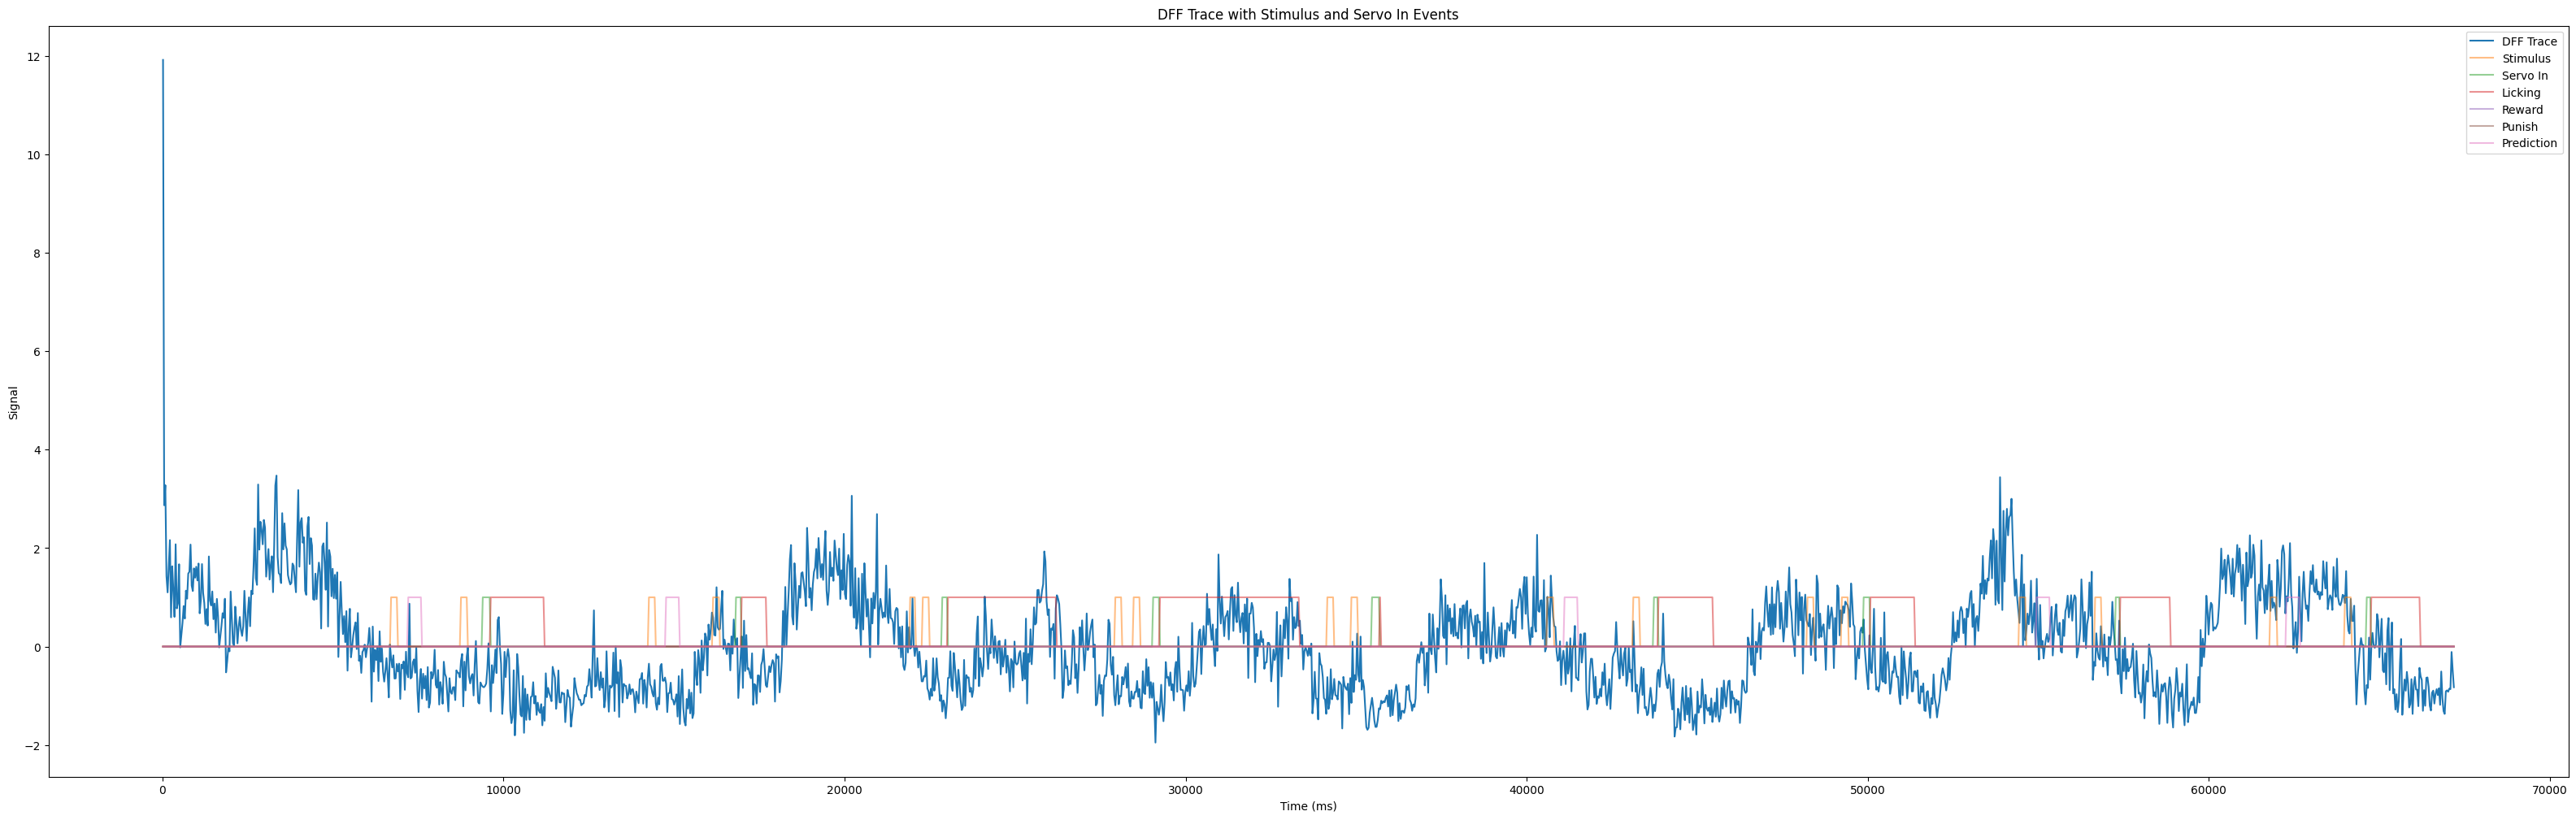

In [87]:
plt.figure(figsize=(40, 12))

plt.plot(time[:2000], dff[0, :2000], label='DFF Trace')
plt.plot(time[:2000], stimulus[0:2000], label='Stimulus', alpha=0.5)
plt.plot(time[:2000], servo_in[0:2000], label='Servo In', alpha=0.5)
plt.plot(time[:2000], licking[0:2000], label='Licking', alpha=0.5)
plt.plot(time[:2000], reward[0:2000], label='Reward', alpha=0.5)
plt.plot(time[:2000], punish[0:2000], label='Punish', alpha=0.5)
plt.plot(time[:2000], predction[0:2000], label='Prediction', alpha=0.5)
plt.xlabel('Time (ms)')
plt.ylabel('Signal')
plt.title('DFF Trace with Stimulus and Servo In Events')
plt.legend()
plt.show()  

In [88]:
from notebook_tools.glm import construct_design_matrix_for_stimulus, create_design_matrix, ridge_regression_bayesian_optimization, compute_explained_variance, fit_glm_for_neuron


Processing session 1/1...
Found 253 neurons.


Fitting neurons:  16%|█▌        | 40/253 [00:12<00:01, 200.92it/s]/home/ihsan/Desktop/data/Georgia_Tech/2AFC/Codes/2p/test/.venv/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [600.0] before, using random point [0.09244170494569583]
  warnings.warn(
/home/ihsan/Desktop/data/Georgia_Tech/2AFC/Codes/2p/test/.venv/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [600.0] before, using random point [307.27416948595646]
  warnings.warn(
/home/ihsan/Desktop/data/Georgia_Tech/2AFC/Codes/2p/test/.venv/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [600.0] before, using random point [0.9866141470668571]
  warnings.warn(
/home/ihsan/Desktop/data/Georgia_Tech/2AFC/Codes/2p/test/.venv/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated


Model processing complete! 🎉


Total neurons analyzed: 253
Best performing neuron is at index: 0
Best explained variance (R^2): 0.209


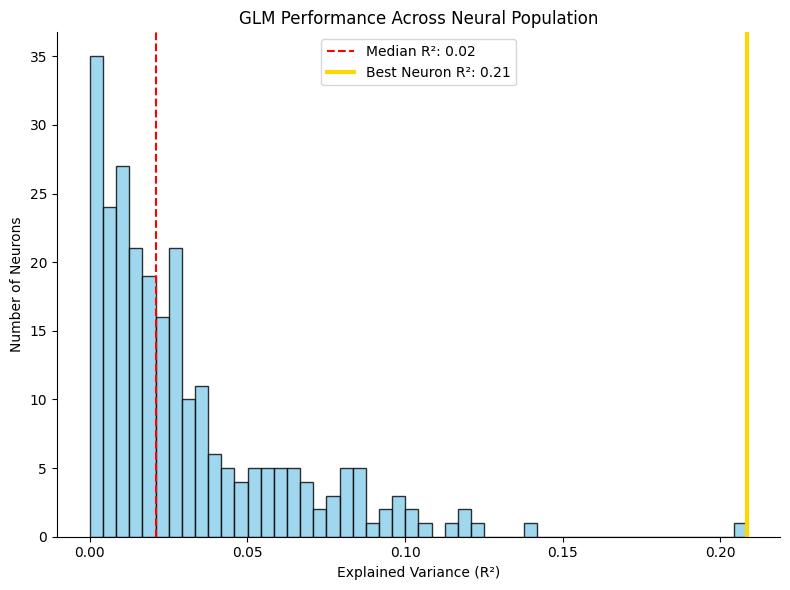

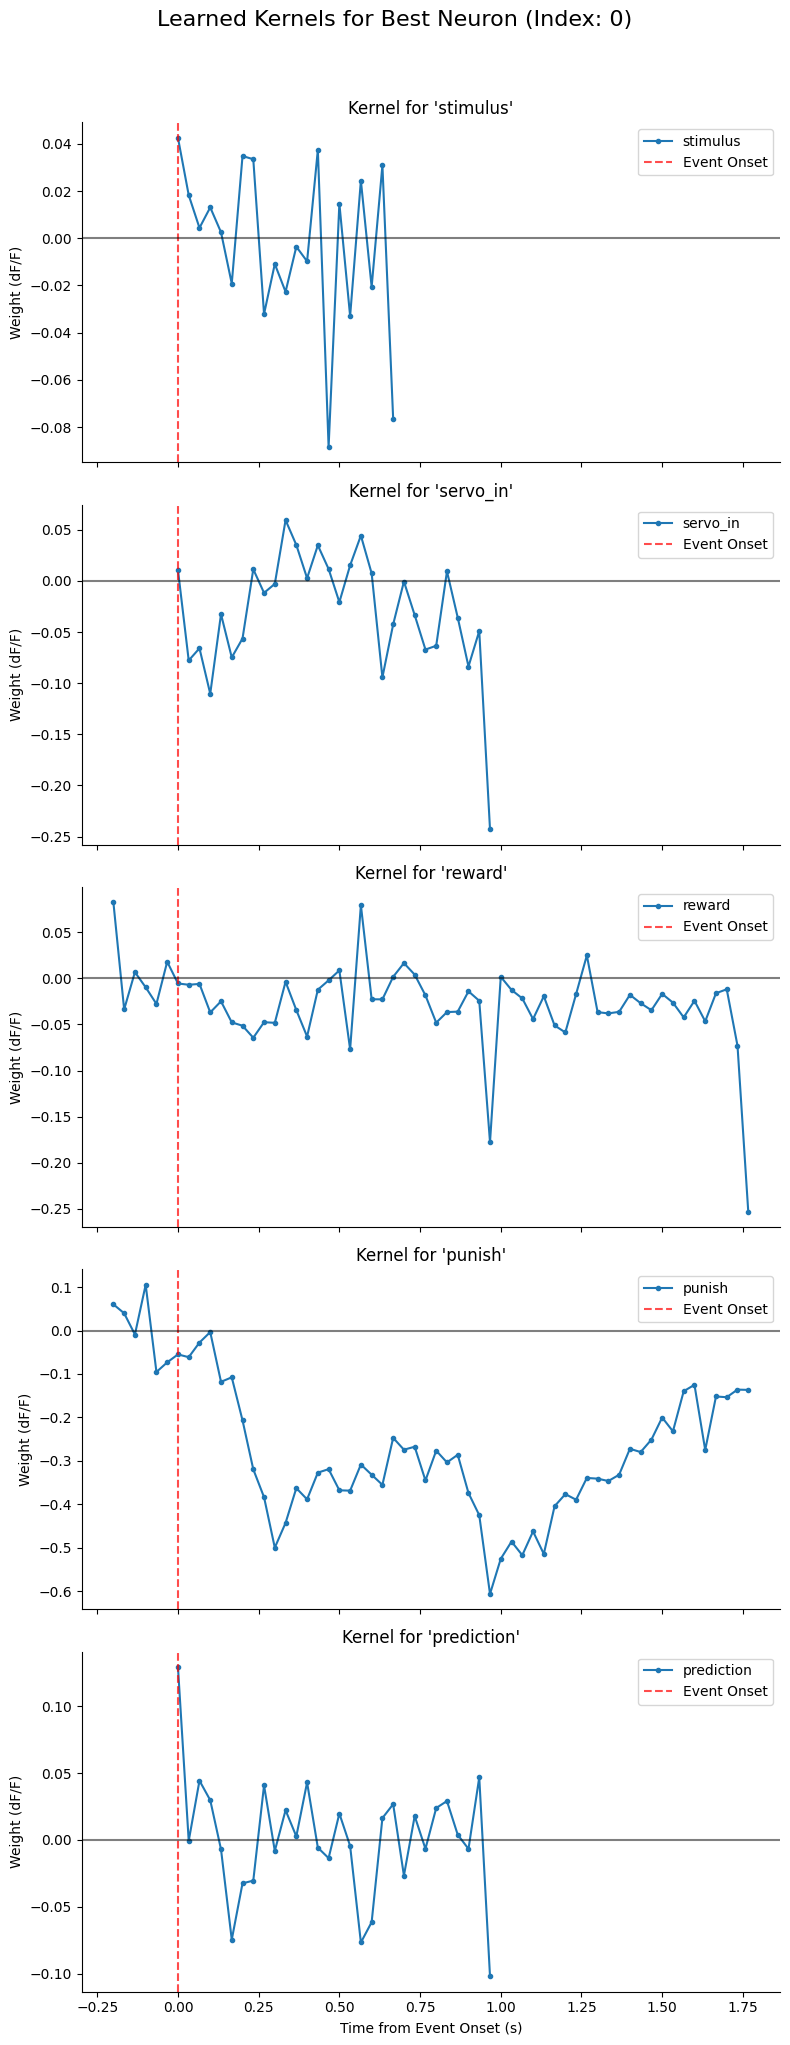

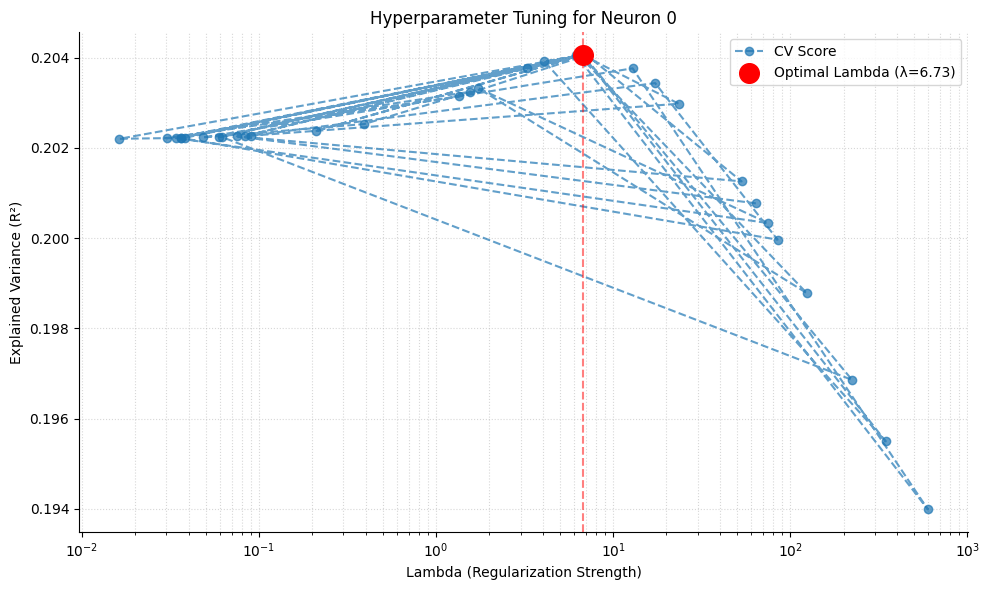

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Data Preparation & Finding the Best Neuron ---

# Assuming 'all_sessions_results' is a list where each item is a neuron's result dictionary.
# If it's a list of lists (one per session), flatten it first:
# all_results_flat = [neuron for session in all_sessions_results for neuron in session]
# The Fix: Flatten the list of lists into a single list of results
all_results_flat = [neuron_result for session_results in all_sessions_results for neuron_result in session_results]

# Now the next line will work correctly
explained_variances = np.array([res['explained_variance_full'] for res in all_results_flat])


# Find the index of the neuron with the highest explained variance
best_neuron_idx = np.argmax(explained_variances)
best_neuron_results = all_results_flat[best_neuron_idx]

print(f"Total neurons analyzed: {len(explained_variances)}")
print(f"Best performing neuron is at index: {best_neuron_idx}")
print(f"Best explained variance (R^2): {explained_variances[best_neuron_idx]:.3f}")


# --- 2. Plot 1: Distribution of Model Performance Across All Neurons ---

plt.figure(figsize=(8, 6))
plt.hist(explained_variances, bins=50, alpha=0.8, color='skyblue', edgecolor='black')
plt.axvline(np.median(explained_variances), color='red', linestyle='--', label=f'Median R²: {np.median(explained_variances):.2f}')
plt.axvline(explained_variances[best_neuron_idx], color='gold', linestyle='-', linewidth=3, label=f'Best Neuron R²: {explained_variances[best_neuron_idx]:.2f}')
plt.xlabel("Explained Variance (R²)")
plt.ylabel("Number of Neurons")
plt.title("GLM Performance Across Neural Population")
plt.legend()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


# --- 3. Plot 2: Learned Kernels for the Best Neuron ---

# Retrieve the full weights vector and kernel configuration
weights = best_neuron_results['weights']
# NOTE: 'kernel_config' and 'fs' should be available from your model fitting script
event_names = list(kernel_config.keys())
n_kernels = len(event_names)

# The first weight is the offset/intercept, so we skip it
kernel_weights = weights[1:]

fig, axes = plt.subplots(n_kernels, 1, figsize=(8, 4 * n_kernels), sharex=True)
if n_kernels == 1: axes = [axes] # Ensure axes is iterable for a single subplot

current_idx = 0
for i, (event_name, config) in enumerate(kernel_config.items()):
    # Get the slice of weights for this kernel
    k_len = config['kernel_length']
    pre_pts = config['pre_points']
    kernel = kernel_weights[current_idx : current_idx + k_len]
    
    # Create a time axis in seconds
    time_axis = np.arange(-pre_pts, k_len - pre_pts) / fs
    
    # Plotting
    ax = axes[i]
    ax.plot(time_axis, kernel, marker='.', linestyle='-', label=event_name)
    ax.axvline(0, color='red', linestyle='--', alpha=0.7, label='Event Onset')
    ax.axhline(0, color='black', linestyle='-', alpha=0.5)
    ax.set_ylabel("Weight (dF/F)")
    ax.set_title(f"Kernel for '{event_name}'")
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    current_idx += k_len

axes[-1].set_xlabel("Time from Event Onset (s)")
fig.suptitle(f"Learned Kernels for Best Neuron (Index: {best_neuron_idx})", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# --- 4. Plot 3: Lambda Optimization Path for the Best Neuron ---

lambda_scores = best_neuron_results['lambda_scores']
best_lambda = best_neuron_results['best_lambda']

# Unzip the lambda-score pairs
lambdas, scores = zip(*lambda_scores)
best_score = max(scores)

plt.figure(figsize=(10, 6))
plt.plot(lambdas, scores, marker='o', linestyle='--', alpha=0.7, label="CV Score")
plt.scatter(best_lambda, best_score, color='red', s=200, label=f'Optimal Lambda (λ={best_lambda:.2f})', zorder=5)

plt.xscale('log')
plt.xlabel("Lambda (Regularization Strength)")
plt.ylabel("Explained Variance (R²)")
plt.title(f"Hyperparameter Tuning for Neuron {best_neuron_idx}")
plt.axvline(x=best_lambda, color='red', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, which="both", ls=":", alpha=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# plt.savefig('lambda_vs_explained_varience_best_neuron.pdf', dpi=600)

# Clustering based on the kernels weight

In [91]:
from notebook_tools.glm import cluster_kernels


### Visualization

PCA captured 95% of variance with 22 components.
Optimal number of clusters found: 2


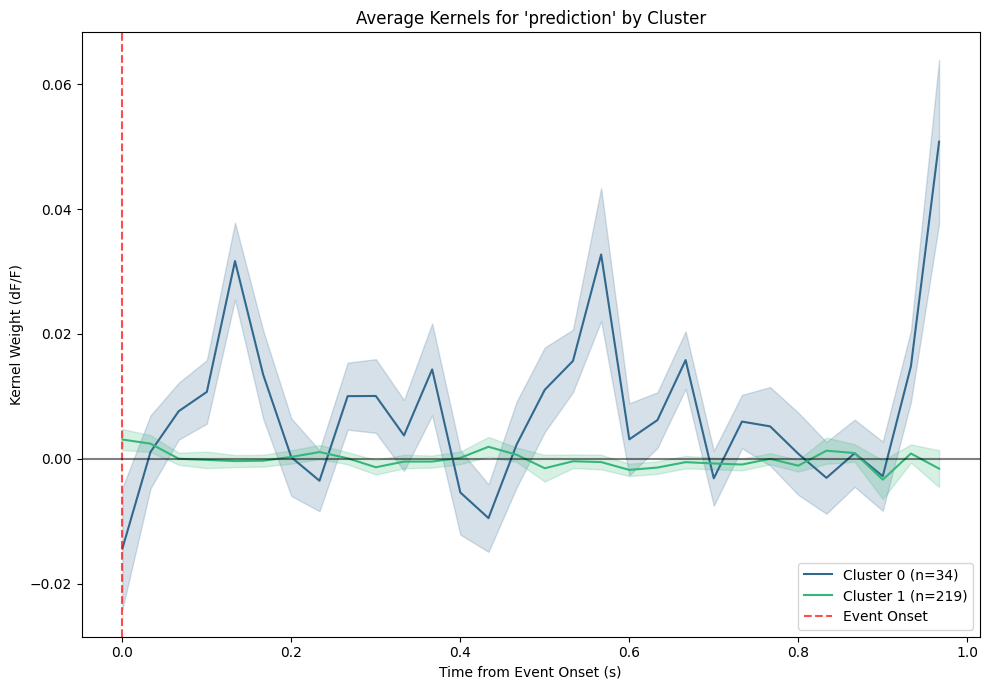

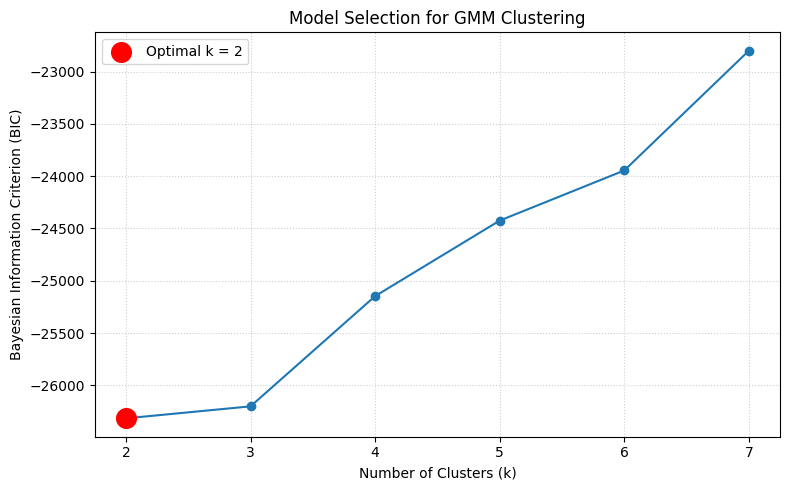

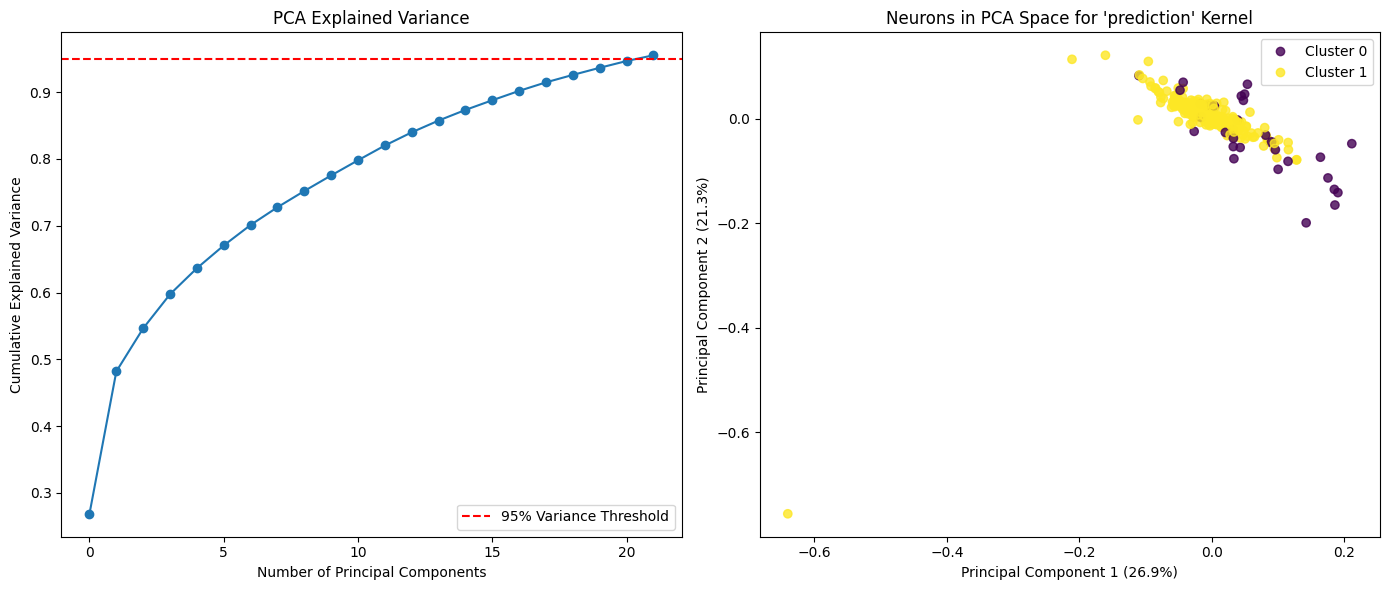

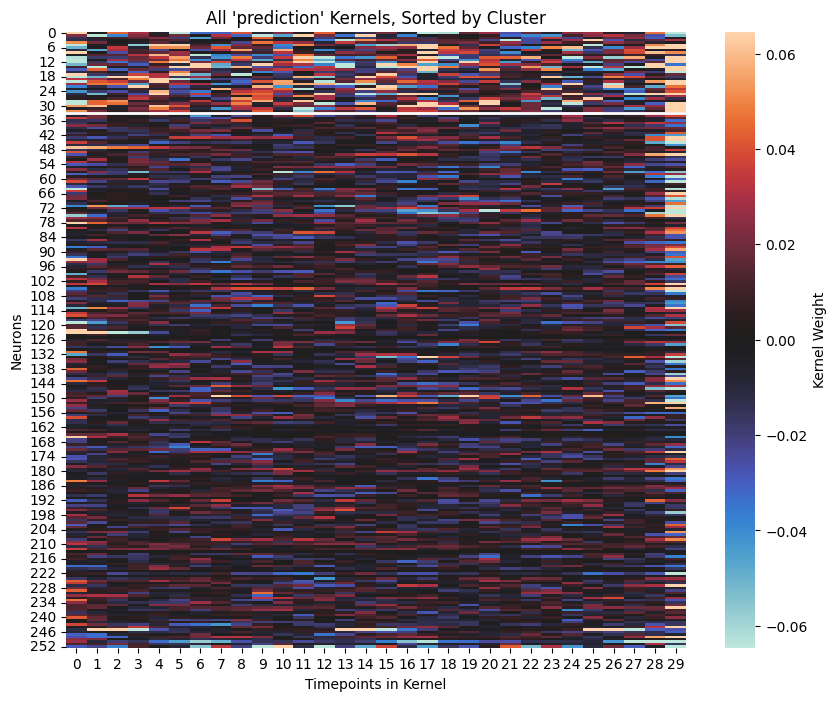

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Run the clustering on the 'prediction' kernel ---
# NOTE: Make sure 'all_results_flat', 'kernel_config', and 'fs' are available
clustering_results = cluster_kernels(
    kernel_name='prediction',
    all_results=all_results_flat,
    kernel_config=kernel_config
)

# Unpack results for easier use
labels = clustering_results['labels']
best_k = clustering_results['best_k']
raw_kernels = clustering_results['raw_kernels']
kernel_name = clustering_results['kernel_name']

# --- Plot 1: Average Kernel for Each Cluster ---
fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette('viridis', n_colors=best_k)

# Create the time axis for the kernel
config = kernel_config[kernel_name]
time_axis = np.arange(-config['pre_points'], config['kernel_length'] - config['pre_points']) / fs

for i in range(best_k):
    cluster_kernels_data = raw_kernels[labels == i]
    mean_kernel = np.mean(cluster_kernels_data, axis=0)
    sem = stats.sem(cluster_kernels_data, axis=0)
    
    ax.plot(time_axis, mean_kernel, color=colors[i], label=f'Cluster {i} (n={len(cluster_kernels_data)})')
    ax.fill_between(time_axis, mean_kernel - sem, mean_kernel + sem, color=colors[i], alpha=0.2)

ax.axvline(0, color='red', linestyle='--', alpha=0.7, label='Event Onset')
ax.axhline(0, color='black', linestyle='-', alpha=0.5)
ax.set_xlabel("Time from Event Onset (s)")
ax.set_ylabel("Kernel Weight (dF/F)")
ax.set_title(f"Average Kernels for '{kernel_name}' by Cluster")
ax.legend()
plt.tight_layout()
plt.show()


# --- Plot 2: Cluster Number Selection (BIC Score) ---
plt.figure(figsize=(8, 5))
plt.plot(clustering_results['n_clusters_range'], clustering_results['bic_scores'], marker='o')
plt.scatter(best_k, min(clustering_results['bic_scores']), color='red', s=200, zorder=5, label=f'Optimal k = {best_k}')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Bayesian Information Criterion (BIC)")
plt.title("Model Selection for GMM Clustering")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


# --- Plot 3 & 4: PCA Results (Explained Variance and Scatter Plot) ---
pca_model = clustering_results['pca_model']
pca_data = clustering_results['pca_data']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 3: Explained Variance
ax1.plot(np.cumsum(pca_model.explained_variance_ratio_), marker='o')
ax1.axhline(0.95, color='red', linestyle='--', label='95% Variance Threshold')
ax1.set_xlabel("Number of Principal Components")
ax1.set_ylabel("Cumulative Explained Variance")
ax1.set_title("PCA Explained Variance")
ax1.legend()

# Plot 4: PCA Trajectory (Scatter)
scatter = ax2.scatter(pca_data[:, 0], pca_data[:, 1], c=labels, cmap='viridis', alpha=0.8)
ax2.set_xlabel(f"Principal Component 1 ({pca_model.explained_variance_ratio_[0]*100:.1f}%)")
ax2.set_ylabel(f"Principal Component 2 ({pca_model.explained_variance_ratio_[1]*100:.1f}%)")
ax2.set_title(f"Neurons in PCA Space for '{kernel_name}' Kernel")
ax2.legend(handles=scatter.legend_elements()[0], labels=[f'Cluster {i}' for i in range(best_k)])
plt.tight_layout()
plt.show()


# --- Bonus Plot: Sorted Kernel Heatmap ---
plt.figure(figsize=(10, 8))
sorted_indices = np.argsort(labels) # Group neurons by cluster
sorted_kernels = raw_kernels[sorted_indices]

# Find boundaries to draw lines between clusters
cluster_boundaries = np.where(np.diff(labels[sorted_indices]))[0] + 0.5

# Use a diverging colormap
vmax = np.percentile(np.abs(sorted_kernels), 98) # For robust color scaling
# Corrected line without the 'aspect' argument
sns.heatmap(sorted_kernels, cmap='icefire', cbar_kws={'label': 'Kernel Weight'}, vmax=vmax, vmin=-vmax)

for boundary in cluster_boundaries:
    plt.axhline(boundary, color='white', lw=2)

plt.title(f"All '{kernel_name}' Kernels, Sorted by Cluster")
plt.xlabel("Timepoints in Kernel")
plt.ylabel("Neurons")
plt.show()

ADD pca 3d trajectories for each clusters


## Alignments 

In [94]:
from notebook_tools.alignment import trim_seq, get_lick_response, get_perception_response


In [97]:
target_state = 'expected_stim'

l_frames, r_frames = 60, 120
[neu_seq, neu_time, stim_seq, stim_value, stim_time, led_value, trial_type, block_type, isi, decision, outcome] = get_perception_response(
        neural_trials, target_state,
        l_frames, r_frames,
        indices = 0
        )

100%|██████████| 403/403 [00:00<00:00, 2325.49it/s]


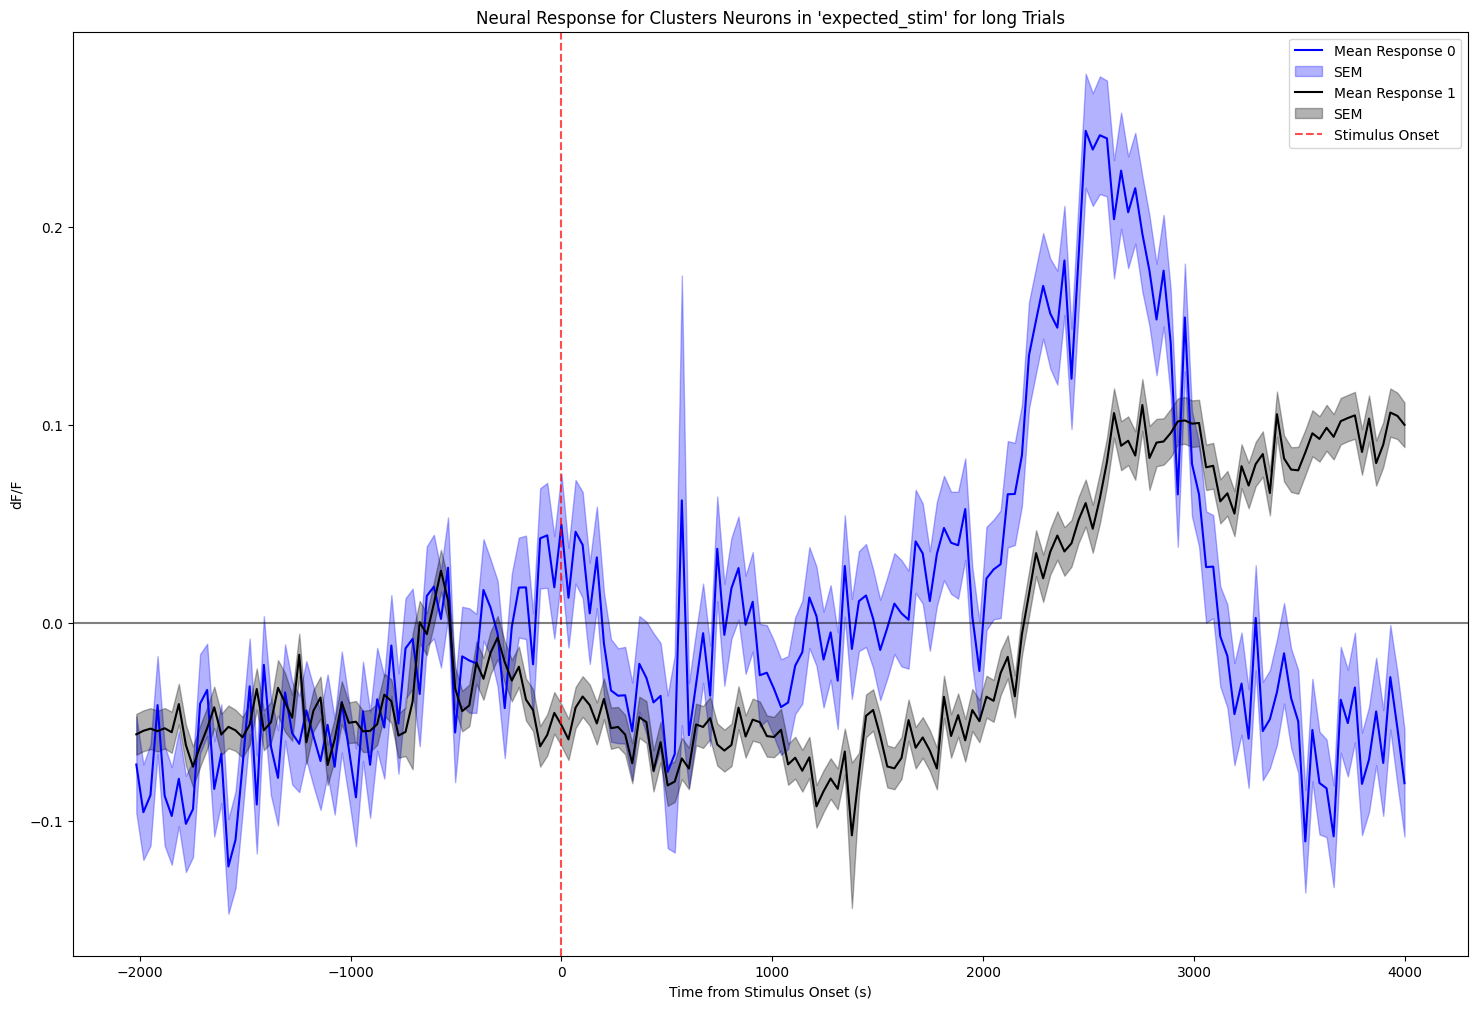

In [106]:
neurons = labels== 0
trial_mask = (trial_type==1) & (block_type==1) & (outcome== 'reward')
x = neu_seq[:, neurons,: ]
x = x[trial_mask,:,:]
mean_response = np.mean(x, axis=(0,1))
sem_response = stats.sem(x, axis=(0,1))
plt.figure(figsize=(18,12))
plt.plot(neu_time, mean_response.T, color='blue', label='Mean Response 0')
plt.fill_between(neu_time, (mean_response - sem_response).T, (mean_response
    + sem_response).T, color='blue', alpha=0.3, label='SEM')

neurons = labels==1
trial_mask = (trial_type==1) & (block_type==1) & (outcome== 'reward')
x = neu_seq[:, neurons,: ]
x = x[trial_mask,:,:]
mean_response = np.mean(x, axis=(0,1))
sem_response = stats.sem(x, axis=(0,1))
plt.plot(neu_time, mean_response.T, color='black', label='Mean Response 1')
plt.fill_between(neu_time, (mean_response - sem_response).T, (mean_response
    + sem_response).T, color='black', alpha=0.3, label='SEM')
plt.axvline(0, color='red', linestyle='--', alpha=0.7, label='Stimulus Onset')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.xlabel("Time from Stimulus Onset (s)")
plt.ylabel("dF/F")
plt.title("Neural Response for Clusters Neurons in 'expected_stim' for long Trials")
plt.legend()

In [ ]:
# import numpy as np
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots
# from scipy.stats import sem
# import pandas as pd
# from dash import Dash, dcc, html, callback, Input, Output, State
# import dash_bootstrap_components as dbc

# # ============================================
# # HELPER FUNCTIONS AND DATASTORAGE CLASS
# # ============================================

# def get_early_late_epochs(block_type, early_n=5, late_n=5):
#     """Label early and late trials in blocks of type 1 and 2."""
#     block_type = np.array(block_type)
#     labels = np.zeros_like(block_type, dtype=int)
    
#     diff = np.diff(block_type, prepend=block_type[0], append=block_type[-1])
#     block_starts = np.where(diff != 0)[0]
#     block_ends = np.where(diff != 0)[0][1:]
#     block_ends = np.append(block_ends, len(block_type))
    
#     for start, end in zip(block_starts, block_ends):
#         block_id = block_type[start]
#         if block_id not in [1, 2]:
#             continue
#         block_length = end - start
#         if block_length < early_n:
#             labels[start:end] = 1
#         else:
#             labels[start:start + early_n] = 1
#             if block_length >= early_n + late_n:
#                 labels[end - late_n:end] = 2
#             elif block_length > early_n:
#                 labels[end - (block_length - early_n):end] = 2
#     return labels

# def compute_avg_and_sem(data, mask, axis=(0, 1)):
#     """Compute mean, SEM, and trial × neuron count for masked data."""
#     masked_data = data[mask, :, :]
#     n_trials, n_neurons, _ = masked_data.shape
#     avg = np.nanmean(masked_data, axis=axis)
#     sem_data = sem(masked_data, axis=axis, nan_policy='omit')
#     return avg, sem_data, n_trials * n_neurons

# def get_y_limits(avg_data1, sem_data1, avg_data2, sem_data2):
#     """Compute y-axis limits from average and SEM data."""
#     if np.all(np.isnan(avg_data1)) and np.all(np.isnan(avg_data2)):
#         return np.nan, np.nan
#     y_min1 = np.nanmin(avg_data1 - sem_data1) if not np.all(np.isnan(avg_data1)) else np.nan
#     y_max1 = np.nanmax(avg_data1 + sem_data1) if not np.all(np.isnan(avg_data1)) else np.nan
#     y_min2 = np.nanmin(avg_data2 - sem_data2) if not np.all(np.isnan(avg_data2)) else np.nan
#     y_max2 = np.nanmax(avg_data2 + sem_data2) if not np.all(np.isnan(avg_data2)) else np.nan
#     y_min = np.nanmin([y_min1, y_min2])
#     y_max = np.nanmax([y_max1, y_max2])
#     return y_min, y_max

# def process_trial_data(neu_seq, neu_time, stim_seq, trial_type, block_type, outcome, 
#                       trial_mask1, trial_mask2, label1, label2, stim_mask, target_state, indices):
#     """Process neural data and stimulus timings for a given alignment and trial conditions."""
#     avg_data1, sem_data1, n_trials_neurons1 = compute_avg_and_sem(neu_seq, trial_mask1)
#     avg_data2, sem_data2, n_trials_neurons2 = compute_avg_and_sem(neu_seq, trial_mask2)
    
#     relevant_trials = trial_mask1 | trial_mask2
#     if target_state == 'stim_seq':
#         stim_idx = indices // 2
#         alignment_times = stim_seq[relevant_trials, stim_idx, 0]
#         adjusted_stim_seq = stim_seq[relevant_trials, :, :] - alignment_times[:, None, None]
#         mean_stim_times = np.nanmean(adjusted_stim_seq, axis=0)
#     else:
#         mean_stim_times = np.nanmean(stim_seq[relevant_trials & stim_mask, :, :], axis=0)
    
#     return neu_time, avg_data1, sem_data1, n_trials_neurons1, avg_data2, sem_data2, n_trials_neurons2, mean_stim_times

# def process_licking_data(licks_per_trial, correctness_per_trial, trial_mask, l_frames, r_frames, frame_rate=30):
#     """Process licking data for a given condition."""
#     time_window_ms = (l_frames + r_frames) / frame_rate * 1000
#     dt_ms = 1000 / frame_rate
#     time_bins = np.arange(-l_frames, r_frames) * dt_ms
    
#     correct_lick_counts = np.zeros((np.sum(trial_mask), len(time_bins) - 1))
#     incorrect_lick_counts = np.zeros((np.sum(trial_mask), len(time_bins) - 1))
    
#     trial_idx = 0
#     for trial in range(len(trial_mask)):
#         if not trial_mask[trial]:
#             continue
        
#         lick_times = licks_per_trial[trial]
#         correctness = correctness_per_trial[trial]
        
#         if len(lick_times) == 0:
#             trial_idx += 1
#             continue
        
#         correct_licks = lick_times[correctness == 1]
#         incorrect_licks = lick_times[correctness == 0]
        
#         if len(correct_licks) > 0:
#             correct_lick_counts[trial_idx, :], _ = np.histogram(correct_licks, bins=time_bins)
        
#         if len(incorrect_licks) > 0:
#             incorrect_lick_counts[trial_idx, :], _ = np.histogram(incorrect_licks, bins=time_bins)
        
#         trial_idx += 1
    
#     dt_sec = dt_ms / 1000
#     correct_lick_rates = correct_lick_counts / dt_sec
#     incorrect_lick_rates = incorrect_lick_counts / dt_sec
    
#     avg_correct = np.nanmean(correct_lick_rates, axis=0)
#     sem_correct = sem(correct_lick_rates, axis=0, nan_policy='omit')
#     n_correct = np.sum(trial_mask)
    
#     avg_incorrect = np.nanmean(incorrect_lick_rates, axis=0)
#     sem_incorrect = sem(incorrect_lick_rates, axis=0, nan_policy='omit')
#     n_incorrect = np.sum(trial_mask)
    
#     lick_time = time_bins[:-1]
    
#     return lick_time, avg_correct, sem_correct, n_correct, avg_incorrect, sem_incorrect, n_incorrect

# def pool_session_data(neural_trials_list, labels_list, cluster_labels, state, l_frames, r_frames, indices, epoch_list=None):
#     """
#     Pool data from multiple sessions, including neural and licking data.
    
#     Args:
#         neural_trials_list: List of session data (neural_trials).
#         labels_list: List of neuron labels per session (e.g., neuron indices).
#         cluster_labels: Array of cluster labels for all neurons.
#         state: Alignment state (e.g., 'time_trial_start', 'state_reward').
#         l_frames, r_frames: Frames before/after alignment point.
#         indices: Index for alignment (e.g., 0 for Stim 1, 2 for Stim 2).
#         epoch_list: List of precomputed epoch arrays per session (optional).
    
#     Returns:
#         tuple: Pooled neu_seq, neu_time, trial_type, block_type, isi, decision, labels, outcomes, stim_seq, epoch (if provided), licks_per_trial, correctness_per_trial, cluster_labels
#     """
#     neu_seqs = []
#     stim_seqs = []
#     trial_types = []
#     block_types = []
#     isis = []
#     decisions = []
#     all_labels = []
#     all_outcomes = []
#     all_epochs = [] if epoch_list is not None else None
#     licks_per_trials = []
#     correctness_per_trials = []

#     neuron_counts = [labels.shape[0] for labels in labels_list]
#     total_neurons = sum(neuron_counts)
#     if total_neurons != len(cluster_labels):
#         raise ValueError(f"Neuron count mismatch: total_neurons={total_neurons}, cluster_labels length={len(cluster_labels)}")

#     neuron_offset = 0
#     for i, (neural_trials, session_labels) in enumerate(zip(neural_trials_list, labels_list)):
#         neu_seq, neu_time, stim_seq, stim_value, stim_time, led_value, trial_type, block_type, isi, decision, outcome = get_perception_response(
#             neural_trials, state, l_frames, r_frames, indices=indices)

#         n_trials, n_neurons, n_time = neu_seq.shape
#         if n_neurons != len(session_labels):
#             raise ValueError(f"Session {i}: neu_seq neuron count ({n_neurons}) does not match labels ({len(session_labels)})")

#         padded_neu_seq = np.full((n_trials, total_neurons, n_time), np.nan)
#         padded_neu_seq[:, neuron_offset:neuron_offset + n_neurons, :] = neu_seq

#         trial_labels = neural_trials['trial_labels']
#         outcome_all = trial_labels['outcome']
#         n_trials_total = len(trial_labels['lick'])
#         trial_indices_to_use = np.arange(2, n_trials_total - 2) if n_trials_total >= 4 else np.array([])
#         licks_per_trial_s = []
#         correctness_per_trial_s = []

#         for trial in range(n_trials_total):
#             if state == 'state_outcome':
#                 start_time_alignment_reward = neural_trials['trial_labels'][state][trial].flatten()[indices]
#                 start_time_alignment_punish = neural_trials['trial_labels'][state][trial].flatten()[indices]
#                 start_time_alignment = start_time_alignment_reward if outcome_all[trial] == 'reward' else start_time_alignment_punish
#             else:
#                 start_time_alignment = neural_trials['trial_labels'][state][trial].flatten()[indices]
#             lick_times = trial_labels['lick'][trial][0] - start_time_alignment
#             correctness = trial_labels['lick'][trial][2]
#             if trial in trial_indices_to_use:
#                 licks_per_trial_s.append(lick_times)
#                 correctness_per_trial_s.append(correctness)

#         neu_seqs.append(padded_neu_seq)
#         stim_seqs.append(stim_seq)
#         trial_types.append(trial_type)
#         block_types.append(block_type)
#         isis.append(isi)
#         decisions.append(decision)
#         all_labels.append(session_labels)
#         all_outcomes.append(outcome)
#         licks_per_trials.append(licks_per_trial_s)
#         correctness_per_trials.append(correctness_per_trial_s)
#         if epoch_list is not None:
#             all_epochs.append(epoch_list[i])

#         neuron_offset += n_neurons

#     pooled_neu_seq = np.concatenate(neu_seqs, axis=0)
#     pooled_stim_seq = np.concatenate(stim_seqs, axis=0)
#     pooled_trial_type = np.concatenate(trial_types, axis=0)
#     pooled_block_type = np.concatenate(block_types, axis=0)
#     pooled_isi = np.concatenate(isis, axis=0)
#     pooled_decision = np.concatenate(decisions, axis=0)
#     pooled_labels = np.concatenate(all_labels, axis=0)
#     pooled_outcomes = np.concatenate(all_outcomes, axis=0)
#     pooled_licks_per_trial = [lick for session_licks in licks_per_trials for lick in session_licks]
#     pooled_correctness_per_trial = [corr for session_corr in correctness_per_trials for corr in session_corr]

#     if epoch_list is not None:
#         pooled_epoch = np.concatenate(all_epochs, axis=0)
#         return (pooled_neu_seq, neu_time, pooled_trial_type, pooled_block_type, pooled_isi, pooled_decision,
#                 pooled_labels, pooled_outcomes, pooled_stim_seq, pooled_epoch, pooled_licks_per_trial, pooled_correctness_per_trial, cluster_labels)
#     return (pooled_neu_seq, neu_time, pooled_trial_type, pooled_block_type, pooled_isi, pooled_decision,
#             pooled_labels, pooled_outcomes, pooled_stim_seq, pooled_licks_per_trial, pooled_correctness_per_trial, cluster_labels)


# class DataStorage:
#     """Store precomputed data for each alignment to avoid recalculation."""
#     def __init__(self):
#         self.data_cache = {}
#         self.cluster_labels = None
    
#     def compute_data(self, neural_trials_list, cluster_labels, l_frames=60, r_frames=120):
#         """Precompute all alignment data for both neural and licking across multiple sessions."""
#         self.cluster_labels = cluster_labels
#         alignments = [
#             ('time_trial_start', 0, 'Trial Start'),
#             ('stim_seq', 0, 'Stim 1 Onset'),
#             ('stim_seq', 2, 'Stim 2 Onset'),
#             ('expected_stim', 0, 'Expected Stimulus'),
#             ('state_window_choice', 0, 'Servo In'),
#             ('state_window_choice', 1, 'Choice'),
#             ('state_outcome', 0, 'Outcome'),
#             ('time_trial_end', 0, 'Trial End'),
#         ]
        
#         row_conditions = [
#             ('Short trials', lambda st, rw, pu, sb, lb, ee, le: (st & rw, st & pu, 'Rewarded', 'Punished', st)),
#             ('Long trials', lambda st, rw, pu, sb, lb, ee, le: ((~st) & rw, (~st) & pu, 'Rewarded', 'Punished', ~st)),
#             ('Short standard trials', lambda st, rw, pu, sb, lb, ee, le: (sb & st & rw, sb & st & pu, 'Rewarded', 'Punished', st)),
#             ('Short rare trials', lambda st, rw, pu, sb, lb, ee, le: (lb & st & rw, lb & st & pu, 'Rewarded', 'Punished', st)),
#             ('Long standard trials', lambda st, rw, pu, sb, lb, ee, le: (lb & (~st) & rw, lb & (~st) & pu, 'Rewarded', 'Punished', ~st)),
#             ('Long rare trials', lambda st, rw, pu, sb, lb, ee, le: (sb & (~st) & rw, sb & (~st) & pu, 'Rewarded', 'Punished', ~st)),
#             ('Early standard short trials', lambda st, rw, pu, sb, lb, ee, le: (ee & sb & st & rw, ee & sb & st & pu, 'Rewarded', 'Punished', st)),
#             ('Late standard short trials', lambda st, rw, pu, sb, lb, ee, le: (le & sb & st & rw, le & sb & st & pu, 'Rewarded', 'Punished', st)),
#             ('Early rare short trials', lambda st, rw, pu, sb, lb, ee, le: (ee & lb & st & rw, ee & lb & st & pu, 'Rewarded', 'Punished', st)),
#             ('Late rare short trials', lambda st, rw, pu, sb, lb, ee, le: (le & lb & st & rw, le & lb & st & pu, 'Rewarded', 'Punished', st)),
#             ('Early standard long trials', lambda st, rw, pu, sb, lb, ee, le: (ee & lb & (~st) & rw, ee & lb & (~st) & pu, 'Rewarded', 'Punished', ~st)),
#             ('Late standard long trials', lambda st, rw, pu, sb, lb, ee, le: (le & lb & (~st) & rw, le & lb & (~st) & pu, 'Rewarded', 'Punished', ~st)),
#             ('Early rare long trials', lambda st, rw, pu, sb, lb, ee, le: (ee & sb & (~st) & rw, ee & sb & (~st) & pu, 'Rewarded', 'Punished', ~st)),
#             ('Late rare long trials', lambda st, rw, pu, sb, lb, ee, le: (le & sb & (~st) & rw, le & sb & (~st) & pu, 'Rewarded', 'Punished', ~st)),
#         ]

#         list_neural_trials = neural_trials_list if isinstance(neural_trials_list, list) else [neural_trials_list]

#         precomputed = []
#         labels_list = []
#         neuron_offset = 0
#         for i, session in enumerate(list_neural_trials):
#             neu_seq_s, _, _, _, _, _, trial_type_s, block_type_s, _, _, outcome_s = get_perception_response(
#                 session, 'time_trial_start', l_frames, r_frames, indices=0)
#             epoch_s = get_early_late_epochs(block_type_s, early_n=5, late_n=5)
#             n_neurons = neu_seq_s.shape[1]  # Number of neurons in this session
#             labels_s = np.arange(neuron_offset, neuron_offset + n_neurons)
#             neuron_offset += n_neurons
#             precomputed.append({
#                 'epoch': epoch_s,
#                 'outcome': outcome_s,
#                 'trial_type': trial_type_s,
#                 'block_type': block_type_s
#             })
#             labels_list.append(labels_s)
#             print(f"Session {i}: n_neurons={n_neurons}, labels_s={labels_s}")

#         total_neurons = sum(len(labels) for labels in labels_list)
#         print(f"Total neurons: {total_neurons}, cluster_labels length: {len(cluster_labels)}")
#         if total_neurons != len(cluster_labels):
#             raise ValueError(f"Mismatch: cluster_labels length ({len(cluster_labels)}) does not match total neurons ({total_neurons})")

#         for target_state, indices, align_label in alignments:
#             if target_state == 'state_outcome':
#                 neu_seq_r, neu_time, trial_type_r, block_type_r, isi_r, decision_r, labels_r, outcome_r, stim_seq_r, epoch_r, licks_r, corr_r, _ = pool_session_data(
#                     list_neural_trials, labels_list, cluster_labels, 'state_reward', l_frames, r_frames, indices=0, epoch_list=[p['epoch'] for p in precomputed])
#                 reward_indices = [np.where(p['outcome'] == 'reward')[0] for p in precomputed]
#                 epoch_r = np.concatenate([p['epoch'][idx] for p, idx in zip(precomputed, reward_indices)], axis=0)
                
#                 neu_seq_p, _, trial_type_p, block_type_p, isi_p, decision_p, labels_p, outcome_p, stim_seq_p, epoch_p, licks_p, corr_p, _ = pool_session_data(
#                     list_neural_trials, labels_list, cluster_labels, 'state_punish', l_frames, r_frames, indices=0, epoch_list=[p['epoch'] for p in precomputed])
#                 punish_indices = [np.where(p['outcome'] == 'punish')[0] for p in precomputed]
#                 epoch_p = np.concatenate([p['epoch'][idx] for p, idx in zip(precomputed, punish_indices)], axis=0)
                
#                 neu_seq = np.concatenate((neu_seq_r, neu_seq_p), axis=0)
#                 print(f"state_outcome: neu_seq_r.shape={neu_seq_r.shape}, neu_seq_p.shape={neu_seq_p.shape}, neu_seq.shape={neu_seq.shape}")
#                 stim_seq = np.concatenate((stim_seq_r, stim_seq_p), axis=0)
#                 trial_type = np.concatenate((trial_type_r, trial_type_p), axis=0)
#                 block_type = np.concatenate((block_type_r, block_type_p), axis=0)
#                 outcome = np.concatenate((outcome_r, outcome_p), axis=0)
#                 epoch = np.concatenate((epoch_r, epoch_p), axis=0)
#                 licks_per_trial = licks_r + licks_p
#                 correctness_per_trial = corr_r + corr_p
#             else:
#                 neu_seq, neu_time, trial_type, block_type, isi, decision, labels, outcome, stim_seq, epoch, licks_per_trial, correctness_per_trial, _ = pool_session_data(
#                     list_neural_trials, labels_list, cluster_labels, target_state, l_frames, r_frames, indices=indices, epoch_list=[p['epoch'] for p in precomputed])
#                 print(f"{align_label}: neu_seq.shape={neu_seq.shape}")

#             early_epoch = epoch == 1
#             late_epoch = epoch == 2
#             short_trials = trial_type == 0
#             long_trials = trial_type == 1
#             rewarded_trials = outcome == 'reward'
#             punished_trials = outcome == 'punish'
#             short_block = block_type == 1
#             long_block = block_type == 2

#             self.data_cache[align_label] = {
#                 'neu_seq': neu_seq,
#                 'neu_time': neu_time,
#                 'stim_seq': stim_seq,
#                 'trial_type': trial_type,
#                 'block_type': block_type,
#                 'outcome': outcome,
#                 'short_trials': short_trials,
#                 'long_trials': long_trials,
#                 'rewarded_trials': rewarded_trials,
#                 'punished_trials': punished_trials,
#                 'short_block': short_block,
#                 'long_block': long_block,
#                 'early_epoch': early_epoch,
#                 'late_epoch': late_epoch,
#                 'licks_per_trial': licks_per_trial,
#                 'correctness_per_trial': correctness_per_trial,
#                 'row_conditions': row_conditions,
#                 'target_state': target_state,
#                 'indices': indices,
#                 'align_label': align_label,
#             }
    
#     def get_figure(self, alignment, selected_conditions, outcomes, mode='separate', selected_clusters=None):
#         """Generate figure for given alignment, conditions, outcomes, and clusters with neural + licking data."""
#         if alignment not in self.data_cache:
#             return go.Figure().add_annotation(text='No data available')
        
#         data = self.data_cache[alignment]
#         neu_seq = data['neu_seq']
        
#         # Filter neural data by selected clusters
#         if selected_clusters and self.cluster_labels is not None:
#             cluster_mask = np.isin(self.cluster_labels, [int(c) for c in selected_clusters])
#             neu_seq = neu_seq[:, cluster_mask, :]
#         else:
#             cluster_mask = np.ones(neu_seq.shape[1], dtype=bool)  # Include all neurons if no clusters selected
        
#         if not np.any(cluster_mask):
#             return go.Figure().add_annotation(text='No neurons in selected clusters')
        
#         y_mins_neural = []
#         y_maxs_neural = []
#         condition_data = {}
#         overall_relevant = np.zeros_like(data['short_trials'], dtype=bool)
        
#         for condition in selected_conditions:
#             mask_func = next(func for title, func in data['row_conditions'] if title == condition)
#             mask1, mask2, label1, label2, stim_mask = mask_func(
#                 data['short_trials'], data['rewarded_trials'], data['punished_trials'],
#                 data['short_block'], data['long_block'], data['early_epoch'], data['late_epoch'])
            
#             if 'rewarded' not in outcomes:
#                 mask1 = np.zeros_like(mask1, dtype=bool)
#             if 'punished' not in outcomes:
#                 mask2 = np.zeros_like(mask2, dtype=bool)
            
#             neu_time, avg_data1, sem_data1, n_trials_neurons1, avg_data2, sem_data2, n_trials_neurons2, mean_stim_times = process_trial_data(
#                 neu_seq, data['neu_time'], data['stim_seq'], data['trial_type'], data['block_type'], data['outcome'],
#                 mask1, mask2, label1, label2, stim_mask, data['target_state'], data['indices']
#             )
            
#             lick_time, avg_correct, sem_correct, n_correct, avg_incorrect, sem_incorrect, n_incorrect = process_licking_data(
#                 data['licks_per_trial'], data['correctness_per_trial'], mask1, l_frames=60, r_frames=120)
            
#             condition_data[condition] = {
#                 'neu_time': neu_time,
#                 'avg_data1': avg_data1, 'sem_data1': sem_data1, 'n1': n_trials_neurons1, 'label1': label1,
#                 'avg_data2': avg_data2, 'sem_data2': sem_data2, 'n2': n_trials_neurons2, 'label2': label2,
#                 'mean_stim_times': mean_stim_times,
#                 'lick_time': lick_time,
#                 'avg_correct': avg_correct, 'sem_correct': sem_correct, 'n_correct': n_correct,
#                 'avg_incorrect': avg_incorrect, 'sem_incorrect': sem_incorrect, 'n_incorrect': n_incorrect,
#             }
            
#             overall_relevant = overall_relevant | (mask1 | mask2)
            
#             y_min, y_max = get_y_limits(avg_data1, sem_data1, avg_data2, sem_data2)
#             if not np.isnan(y_min):
#                 y_mins_neural.append(y_min)
#             if not np.isnan(y_max):
#                 y_maxs_neural.append(y_max)
        
#         if not y_mins_neural or not y_maxs_neural:
#             y_lim_neural = (-0.1, 0.1)
#         else:
#             y_min = min(y_mins_neural)
#             y_max = max(y_maxs_neural)
#             y_range = y_max - y_min
#             y_lim_neural = (y_min - 0.1 * y_range, y_max + 0.1 * y_range) if y_range > 0 else (-0.1, 0.1)
        
#         if np.any(overall_relevant):
#             if data['target_state'] == 'stim_seq':
#                 stim_idx = data['indices'] // 2
#                 alignment_times = data['stim_seq'][overall_relevant, stim_idx, 0]
#                 adjusted_stim_seq = data['stim_seq'][overall_relevant, :, :] - alignment_times[:, None, None]
#                 overall_mean_stim_times = np.nanmean(adjusted_stim_seq, axis=0)
#             else:
#                 overall_stim_mask = np.ones_like(overall_relevant, dtype=bool)
#                 overall_mean_stim_times = np.nanmean(data['stim_seq'][overall_relevant & overall_stim_mask, :, :], axis=0)
#         else:
#             overall_mean_stim_times = np.full((2, 2), np.nan)
        
#         if mode == 'superimposed':
#             fig = make_subplots(
#                 rows=2, cols=1,
#                 shared_xaxes=True,
#                 vertical_spacing=0.15,
#                 row_heights=[0.5, 0.5],
#                 subplot_titles=('Neural Activity', 'Licking Rate')
#             )
            
#             dash_styles = ['solid', 'dot', 'dash', 'longdash', 'dashdot', 'longdashdot']
            
#             for i, condition in enumerate(selected_conditions):
#                 cdata = condition_data[condition]
#                 dash = dash_styles[i % len(dash_styles)]
                
#                 if 'rewarded' in outcomes and not np.all(np.isnan(cdata['avg_data1'])):
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['neu_time'],
#                             y=cdata['avg_data1'] + cdata['sem_data1'],
#                             mode='lines',
#                             line=dict(color='rgba(0,0,0,0)'),
#                             showlegend=False,
#                             hoverinfo='none'
#                         ),
#                         row=1, col=1
#                     )
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['neu_time'],
#                             y=cdata['avg_data1'] - cdata['sem_data1'],
#                             mode='lines',
#                             fill='tonexty',
#                             fillcolor='rgba(0, 255, 0, 0.3)',
#                             line=dict(color='rgba(0,0,0,0)'),
#                             showlegend=False,
#                             hoverinfo='none'
#                         ),
#                         row=1, col=1
#                     )
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['neu_time'],
#                             y=cdata['avg_data1'],
#                             mode='lines',
#                             name=f"{condition} - Neural {cdata['label1']} (n={cdata['n1']})",
#                             line=dict(color='green', width=2, dash=dash),
#                             hovertemplate='<b>%{fullData.name}</b><br>Time: %{x:.1f} ms<br>Mean: %{y:.3f}<extra></extra>',
#                             legendgroup=f'neural_{i}'
#                         ),
#                         row=1, col=1
#                     )
                
#                 if 'punished' in outcomes and not np.all(np.isnan(cdata['avg_data2'])):
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['neu_time'],
#                             y=cdata['avg_data2'] + cdata['sem_data2'],
#                             mode='lines',
#                             line=dict(color='rgba(0,0,0,0)'),
#                             showlegend=False,
#                             hoverinfo='none'
#                         ),
#                         row=1, col=1
#                     )
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['neu_time'],
#                             y=cdata['avg_data2'] - cdata['sem_data2'],
#                             mode='lines',
#                             fill='tonexty',
#                             fillcolor='rgba(255, 0, 0, 0.3)',
#                             line=dict(color='rgba(0,0,0,0)'),
#                             showlegend=False,
#                             hoverinfo='none'
#                         ),
#                         row=1, col=1
#                     )
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['neu_time'],
#                             y=cdata['avg_data2'],
#                             mode='lines',
#                             name=f"{condition} - Neural {cdata['label2']} (n={cdata['n2']})",
#                             line=dict(color='red', width=2, dash=dash),
#                             hovertemplate='<b>%{fullData.name}</b><br>Time: %{x:.1f} ms<br>Mean: %{y:.3f}<extra></extra>',
#                             legendgroup=f'neural_{i}'
#                         ),
#                         row=1, col=1
#                     )
                
#                 if not np.all(np.isnan(cdata['avg_correct'])):
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['lick_time'],
#                             y=cdata['avg_correct'] + cdata['sem_correct'],
#                             mode='lines',
#                             line=dict(color='rgba(0,0,0,0)'),
#                             showlegend=False,
#                             hoverinfo='none'
#                         ),
#                         row=2, col=1
#                     )
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['lick_time'],
#                             y=cdata['avg_correct'] - cdata['sem_correct'],
#                             mode='lines',
#                             fill='tonexty',
#                             fillcolor='rgba(0, 255, 0, 0.3)',
#                             line=dict(color='rgba(0,0,0,0)'),
#                             showlegend=False,
#                             hoverinfo='none'
#                         ),
#                         row=2, col=1
#                     )
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['lick_time'],
#                             y=cdata['avg_correct'],
#                             mode='lines',
#                             name=f"{condition} - Correct Licks (n={cdata['n_correct']})",
#                             line=dict(color='green', width=2, dash=dash),
#                             hovertemplate='<b>%{fullData.name}</b><br>Time: %{x:.1f} ms<br>Rate: %{y:.2f} licks/s<extra></extra>',
#                             legendgroup=f'lick_{i}'
#                         ),
#                         row=2, col=1
#                     )
                
#                 if not np.all(np.isnan(cdata['avg_incorrect'])):
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['lick_time'],
#                             y=cdata['avg_incorrect'] + cdata['sem_incorrect'],
#                             mode='lines',
#                             line=dict(color='rgba(0,0,0,0)'),
#                             showlegend=False,
#                             hoverinfo='none'
#                         ),
#                         row=2, col=1
#                     )
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['lick_time'],
#                             y=cdata['avg_incorrect'] - cdata['sem_incorrect'],
#                             mode='lines',
#                             fill='tonexty',
#                             fillcolor='rgba(255, 0, 0, 0.3)',
#                             line=dict(color='rgba(0,0,0,0)'),
#                             showlegend=False,
#                             hoverinfo='none'
#                         ),
#                         row=2, col=1
#                     )
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['lick_time'],
#                             y=cdata['avg_incorrect'],
#                             mode='lines',
#                             name=f"{condition} - Incorrect Licks (n={cdata['n_incorrect']})",
#                             line=dict(color='red', width=2, dash=dash),
#                             hovertemplate='<b>%{fullData.name}</b><br>Time: %{x:.1f} ms<br>Rate: %{y:.2f} licks/s<extra></extra>',
#                             legendgroup=f'lick_{i}'
#                         ),
#                         row=2, col=1
#                     )
            
#             if not np.all(np.isnan(overall_mean_stim_times)):
#                 for stim_idx in range(2):
#                     start_time = overall_mean_stim_times[stim_idx, 0]
#                     end_time = overall_mean_stim_times[stim_idx, 1]
#                     if np.isfinite(start_time) and np.isfinite(end_time):
#                         for row in [1, 2]:
#                             fig.add_shape(
#                                 type='rect',
#                                 x0=start_time,
#                                 x1=end_time,
#                                 y0=0 if row == 2 else y_lim_neural[0],
#                                 y1=10 if row == 2 else y_lim_neural[1],
#                                 fillcolor='blue' if stim_idx == 0 else 'purple',
#                                 opacity=0.2,
#                                 layer='below',
#                                 line_width=0,
#                             )
            
#             fig.update_layout(
#                 title=f'Neural and Licking Data - {alignment}' + (f' (Clusters: {", ".join(map(str, selected_clusters))})' if selected_clusters else ' (All Clusters)'),
#                 height=600,
#                 showlegend=True,
#                 template='plotly_white',
#             )
#             fig.update_xaxes(title_text='Time (ms)', row=2, col=1)
#             fig.update_yaxes(title_text='Neural Activity', row=1, col=1, range=y_lim_neural)
#             fig.update_yaxes(title_text='Lick Rate (licks/s)', row=2, col=1, range=[0, 10])
        
#         else:  # mode == 'separate'
#             n_conditions = len(selected_conditions)
#             fig = make_subplots(
#                 rows=n_conditions * 2,
#                 cols=1,
#                 shared_xaxes=True,
#                 vertical_spacing=0.1,
#                 row_heights=[0.5 / n_conditions] * (n_conditions * 2),
#                 subplot_titles=[f"{cond} - Neural Activity" if i % 2 == 0 else f"{cond} - Licking Rate"
#                                 for i, cond in enumerate(selected_conditions * 2)]
#             )
            
#             for i, condition in enumerate(selected_conditions):
#                 cdata = condition_data[condition]
#                 row_neural = i * 2 + 1
#                 row_lick = i * 2 + 2
                
#                 if 'rewarded' in outcomes and not np.all(np.isnan(cdata['avg_data1'])):
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['neu_time'],
#                             y=cdata['avg_data1'] + cdata['sem_data1'],
#                             mode='lines',
#                             line=dict(color='rgba(0,0,0,0)'),
#                             showlegend=False,
#                             hoverinfo='none'
#                         ),
#                         row=row_neural, col=1
#                     )
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['neu_time'],
#                             y=cdata['avg_data1'] - cdata['sem_data1'],
#                             mode='lines',
#                             fill='tonexty',
#                             fillcolor='rgba(0, 255, 0, 0.3)',
#                             line=dict(color='rgba(0,0,0,0)'),
#                             showlegend=False,
#                             hoverinfo='none'
#                         ),
#                         row=row_neural, col=1
#                     )
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['neu_time'],
#                             y=cdata['avg_data1'],
#                             mode='lines',
#                             name=f"Neural {cdata['label1']} (n={cdata['n1']})",
#                             line=dict(color='green', width=2),
#                             hovertemplate='<b>%{fullData.name}</b><br>Time: %{x:.1f} ms<br>Mean: %{y:.3f}<extra></extra>',
#                             legendgroup=f'neural_{i}'
#                         ),
#                         row=row_neural, col=1
#                     )
                
#                 if 'punished' in outcomes and not np.all(np.isnan(cdata['avg_data2'])):
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['neu_time'],
#                             y=cdata['avg_data2'] + cdata['sem_data2'],
#                             mode='lines',
#                             line=dict(color='rgba(0,0,0,0)'),
#                             showlegend=False,
#                             hoverinfo='none'
#                         ),
#                         row=row_neural, col=1
#                     )
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['neu_time'],
#                             y=cdata['avg_data2'] - cdata['sem_data2'],
#                             mode='lines',
#                             fill='tonexty',
#                             fillcolor='rgba(255, 0, 0, 0.3)',
#                             line=dict(color='rgba(0,0,0,0)'),
#                             showlegend=False,
#                             hoverinfo='none'
#                         ),
#                         row=row_neural, col=1
#                     )
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['neu_time'],
#                             y=cdata['avg_data2'],
#                             mode='lines',
#                             name=f"Neural {cdata['label2']} (n={cdata['n2']})",
#                             line=dict(color='red', width=2),
#                             hovertemplate='<b>%{fullData.name}</b><br>Time: %{x:.1f} ms<br>Mean: %{y:.3f}<extra></extra>',
#                             legendgroup=f'neural_{i}'
#                         ),
#                         row=row_neural, col=1
#                     )
                
#                 if not np.all(np.isnan(cdata['avg_correct'])):
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['lick_time'],
#                             y=cdata['avg_correct'] + cdata['sem_correct'],
#                             mode='lines',
#                             line=dict(color='rgba(0,0,0,0)'),
#                             showlegend=False,
#                             hoverinfo='none'
#                         ),
#                         row=row_lick, col=1
#                     )
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['lick_time'],
#                             y=cdata['avg_correct'] - cdata['sem_correct'],
#                             mode='lines',
#                             fill='tonexty',
#                             fillcolor='rgba(0, 255, 0, 0.3)',
#                             line=dict(color='rgba(0,0,0,0)'),
#                             showlegend=False,
#                             hoverinfo='none'
#                         ),
#                         row=row_lick, col=1
#                     )
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['lick_time'],
#                             y=cdata['avg_correct'],
#                             mode='lines',
#                             name=f"Correct Licks (n={cdata['n_correct']})",
#                             line=dict(color='green', width=2),
#                             hovertemplate='<b>%{fullData.name}</b><br>Time: %{x:.1f} ms<br>Rate: %{y:.2f} licks/s<extra></extra>',
#                             legendgroup=f'lick_{i}'
#                         ),
#                         row=row_lick, col=1
#                     )
                
#                 if not np.all(np.isnan(cdata['avg_incorrect'])):
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['lick_time'],
#                             y=cdata['avg_incorrect'] + cdata['sem_incorrect'],
#                             mode='lines',
#                             line=dict(color='rgba(0,0,0,0)'),
#                             showlegend=False,
#                             hoverinfo='none'
#                         ),
#                         row=row_lick, col=1
#                     )
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['lick_time'],
#                             y=cdata['avg_incorrect'] - cdata['sem_incorrect'],
#                             mode='lines',
#                             fill='tonexty',
#                             fillcolor='rgba(255, 0, 0, 0.3)',
#                             line=dict(color='rgba(0,0,0,0)'),
#                             showlegend=False,
#                             hoverinfo='none'
#                         ),
#                         row=row_lick, col=1
#                     )
#                     fig.add_trace(
#                         go.Scatter(
#                             x=cdata['lick_time'],
#                             y=cdata['avg_incorrect'],
#                             mode='lines',
#                             name=f"Incorrect Licks (n={cdata['n_incorrect']})",
#                             line=dict(color='red', width=2),
#                             hovertemplate='<b>%{fullData.name}</b><br>Time: %{x:.1f} ms<br>Rate: %{y:.2f} licks/s<extra></extra>',
#                             legendgroup=f'lick_{i}'
#                         ),
#                         row=row_lick, col=1
#                     )
                
#                 if not np.all(np.isnan(cdata['mean_stim_times'])):
#                     for stim_idx in range(2):
#                         start_time = cdata['mean_stim_times'][stim_idx, 0]
#                         end_time = cdata['mean_stim_times'][stim_idx, 1]
#                         if np.isfinite(start_time) and np.isfinite(end_time):
#                             fig.add_shape(
#                                 type='rect',
#                                 x0=start_time,
#                                 x1=end_time,
#                                 y0=y_lim_neural[0],
#                                 y1=y_lim_neural[1],
#                                 fillcolor='blue' if stim_idx == 0 else 'purple',
#                                 opacity=0.2,
#                                 layer='below',
#                                 line_width=0,
#                                 row=row_neural,
#                                 col=1
#                             )
#                             fig.add_shape(
#                                 type='rect',
#                                 x0=start_time,
#                                 x1=end_time,
#                                 y0=0,
#                                 y1=10,
#                                 fillcolor='blue' if stim_idx == 0 else 'purple',
#                                 opacity=0.2,
#                                 layer='below',
#                                 line_width=0,
#                                 row=row_lick,
#                                 col=1
#                             )
            
#             fig.update_layout(
#                 title=f'Neural and Licking Data - {alignment}' + (f' (Clusters: {", ".join(map(str, selected_clusters))})' if selected_clusters else ' (All Clusters)'),
#                 height=300 * n_conditions,
#                 showlegend=True,
#                 template='plotly_white',
#             )
#             for i in range(n_conditions):
#                 fig.update_yaxes(title_text='Neural Activity', row=i * 2 + 1, col=1, range=y_lim_neural)
#                 fig.update_yaxes(title_text='Lick Rate (licks/s)', row=i * 2 + 2, col=1, range=[0, 10])
#             fig.update_xaxes(title_text='Time (ms)', row=n_conditions * 2, col=1)
        
#         return fig

# # Initialize data storage
# data_storage = DataStorage()

# # Verify get_figure exists
# print("Checking DataStorage methods:", [method for method in dir(data_storage) if not method.startswith('__')])

# # Initialize Dash app
# app = Dash(__name__, external_stylesheets=[dbc.themes.BOOTSTRAP])

# # Define app layout
# app.layout = dbc.Container([
#     dbc.Row([
#         dbc.Col([
#             html.H1('Interactive Neural Traces Viewer', className='text-center my-4 text-primary')
#         ], width=12)
#     ]),
    
#     dbc.Row([
#         dbc.Col([
#             html.Label('Select Alignment:', className='fw-bold mb-2'),
#             dcc.Dropdown(
#                 id='alignment-selector',
#                 options=[
#                     {'label': 'Trial Start', 'value': 'Trial Start'},
#                     {'label': 'Stim 1 Onset', 'value': 'Stim 1 Onset'},
#                     {'label': 'Stim 2 Onset', 'value': 'Stim 2 Onset'},
#                     {'label': 'Expected Stimulus', 'value': 'Expected Stimulus'},
#                     {'label': 'Servo In', 'value': 'Servo In'},
#                     {'label': 'Choice', 'value': 'Choice'},
#                     {'label': 'Outcome', 'value': 'Outcome'},
#                     {'label': 'Trial End', 'value': 'Trial End'},
#                 ],
#                 value='Trial Start',
#                 clearable=False,
#                 className='mb-3'
#             )
#         ], md=3, className='p-2'),
        
#         dbc.Col([
#             html.Label('Outcome:', className='fw-bold mb-2'),
#             dcc.Checklist(
#                 id='outcome-selector',
#                 options=[
#                     {'label': ' Rewarded', 'value': 'rewarded'},
#                     {'label': ' Punished', 'value': 'punished'}
#                 ],
#                 value=['rewarded', 'punished'],
#                 inline=True,
#                 className='mb-3'
#             )
#         ], md=3, className='p-2'),
        
#         dbc.Col([
#             html.Label('Plot Mode:', className='fw-bold mb-2'),
#             dcc.RadioItems(
#                 id='plot-mode',
#                 options=[
#                     {'label': ' Separate Subplots', 'value': 'separate'},
#                     {'label': ' Superimposed', 'value': 'superimposed'}
#                 ],
#                 value='separate',
#                 inline=True,
#                 className='mb-3'
#             )
#         ], md=3, className='p-2'),
        
#         dbc.Col([
#             html.Label('Select Clusters:', className='fw-bold mb-2'),
#             dcc.Dropdown(
#                 id='cluster-selector',
#                 options=[{'label': f'Cluster {i}', 'value': str(i)} for i in range(10)],  # Adjust range based on max clusters
#                 multi=True,
#                 value=None,
#                 placeholder='Select clusters (leave empty for all)',
#                 className='mb-3'
#             )
#         ], md=3, className='p-2'),
#     ], className='mb-4 p-3 bg-light rounded shadow-sm'),
    
#     dbc.Row([
#         dbc.Col([
#             html.Label('Select Conditions:', className='fw-bold mb-2'),
#             dcc.Checklist(
#                 id='condition-selector',
#                 options=[
#                     {'label': ' Short trials', 'value': 'Short trials'},
#                     {'label': ' Long trials', 'value': 'Long trials'},
#                     {'label': ' Short standard trials', 'value': 'Short standard trials'},
#                     {'label': ' Short rare trials', 'value': 'Short rare trials'},
#                     {'label': ' Long standard trials', 'value': 'Long standard trials'},
#                     {'label': ' Long rare trials', 'value': 'Long rare trials'},
#                     {'label': ' Early standard short trials', 'value': 'Early standard short trials'},
#                     {'label': ' Late standard short trials', 'value': 'Late standard short trials'},
#                     {'label': ' Early rare short trials', 'value': 'Early rare short trials'},
#                     {'label': ' Late rare short trials', 'value': 'Late rare short trials'},
#                     {'label': ' Early standard long trials', 'value': 'Early standard long trials'},
#                     {'label': ' Late standard long trials', 'value': 'Late standard long trials'},
#                     {'label': ' Early rare long trials', 'value': 'Early rare long trials'},
#                     {'label': ' Late rare long trials', 'value': 'Late rare long trials'},
#                 ],
#                 value=['Short trials'],
#                 inline=False,
#                 className='mb-3'
#             )
#         ], md=12, className='p-2')
#     ], className='mb-4 p-3 bg-light rounded shadow-sm'),
    
#     dbc.Row([
#         dbc.Col([
#             dcc.Graph(id='neural-plot', style={'height': '80vh'})
#         ], width=12)
#     ]),
    
#     dcc.Loading(
#         id='loading',
#         type='circle',
#         children=[html.Div(id='loading-output')]
#     )
# ], fluid=True, className='py-4 bg-secondary-subtle')

# # Callback to update plot
# @app.callback(
#     Output('neural-plot', 'figure'),
#     Output('loading-output', 'children'),
#     Input('alignment-selector', 'value'),
#     Input('condition-selector', 'value'),
#     Input('outcome-selector', 'value'),
#     Input('plot-mode', 'value'),
#     Input('cluster-selector', 'value')
# )
# def update_plot(alignment, conditions, outcomes, mode, selected_clusters):
#     """Update plot when alignment, conditions, outcomes, mode, or clusters change."""
#     if not conditions or not outcomes:
#         fig = go.Figure()
#         fig.add_annotation(
#             text='Please select at least one condition and one outcome.',
#             xref='paper', yref='paper',
#             x=0.5, y=0.5,
#             showarrow=False,
#             font=dict(size=20)
#         )
#         return fig, ''
    
#     try:
#         fig = data_storage.get_figure(alignment, conditions, outcomes, mode, selected_clusters)
#         return fig, ''
#     except Exception as e:
#         fig = go.Figure()
#         fig.add_annotation(
#             text=f'Error generating plot: {str(e)}',
#             xref='paper', yref='paper',
#             x=0.5, y=0.5,
#             showarrow=False,
#             font=dict(size=20)
#         )
#         return fig, ''

# # Run the app
# if __name__ == '__main__':
#     print("Computing data for all alignments... This may take a minute...")
#     try:
#         # Replace neural_trials with _neural_trials (list of sessions) and cluster_labels from clustering
#         cluster_labels = cluster_kernels(kernel_name='prediction', all_results=all_results_flat, kernel_config=kernel_config)['labels']
#         data_storage.compute_data(list_neural_trials, cluster_labels, l_frames=60, r_frames=120)
#         print("Data ready!")
#     except NameError:
#         print("Warning: _neural_trials or cluster_labels not defined. Please load data and cluster labels before running compute_data.")
    
#     print("Starting app...")
#     app.run(debug=True)

Exception in thread Thread-690 (bg_main):
Traceback (most recent call last):
  File "/tmp/ipykernel_39921/2607113068.py", line 17, in bg_main
  File "/home/ihsan/Desktop/data/Georgia_Tech/2AFC/Codes/2p/test/.venv/lib/python3.10/site-packages/IPython/core/display_functions.py", line 374, in update
    update_display(obj, display_id=self.display_id, **kwargs)
  File "/home/ihsan/Desktop/data/Georgia_Tech/2AFC/Codes/2p/test/.venv/lib/python3.10/site-packages/IPython/core/display_functions.py", line 326, in update_display
    display(obj, display_id=display_id, **kwargs)
  File "/home/ihsan/Desktop/data/Georgia_Tech/2AFC/Codes/2p/test/.venv/lib/python3.10/site-packages/IPython/core/display_functions.py", line 296, in display
    publish_display_data(data=obj, metadata=metadata, **kwargs)
  File "/home/ihsan/Desktop/data/Georgia_Tech/2AFC/Codes/2p/test/.venv/lib/python3.10/site-packages/IPython/core/display_functions.py", line 93, in publish_display_data
    display_pub.publish(
  File "/ho